# Expected directed-F1 of the structure-blind random baseline

Goal: visualize the random-baseline directed-F1 surface and use it to calibrate the v1 ladder's identifiability axis.

Two forms (derived in conversation):

$$\text{E}[F_1 \mid m] = \frac{\rho \, s}{s + \rho}, \qquad s = \frac{m}{M}, \quad \rho = \frac{k}{M}, \quad M = \frac{d(d-1)}{2}$$

$$\text{E}[F_1] \approx \frac{\rho}{1 + 2\rho} \quad \text{(at } s = \tfrac{1}{2}\text{)}$$

The first is the conditional expectation given the baseline submitted exactly $m$ edges. The second is the closed form at the midpoint submission rate $s = \tfrac{1}{2}$, which is what our random baseline averages to in expectation (it draws $m$ uniform on $\{0, \ldots, M\}$).

No LLM agent overlays in this notebook — purely the random floor and where v1 should land on it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RANDOM_LONG = ROOT / "traces" / "ladder" / "random_uniform_baseline" / "results_random_dag_long.csv"
RANDOM_SUMMARY = ROOT / "traces" / "ladder" / "random_uniform_baseline" / "results_random_dag_summary.csv"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

INK = "#222222"
MUTED = "#707070"
ACCENT = "#2b6cb0"
ACCENT2 = "#b45309"

## Formulas

In [2]:
def expected_f1_conditional(rho, s):
    """E[F1 | m] = rho*s / (s + rho). Vectorized over rho and s."""
    rho = np.asarray(rho, dtype=float)
    s = np.asarray(s, dtype=float)
    denom = s + rho
    return np.where(denom > 0, rho * s / denom, 0.0)


def expected_f1_marginal(rho, n_grid=1001):
    """E[F1] averaged over s uniform on [0, 1]. Returns scalar or array."""
    rho = np.asarray(rho, dtype=float)
    s = np.linspace(0.0, 1.0, n_grid)
    rho_b = rho[..., None]
    s_b = s[None, ...] if rho.ndim else s
    vals = np.where(s_b + rho_b > 0, rho_b * s_b / (s_b + rho_b), 0.0)
    return vals.mean(axis=-1)


def closed_form_midpoint(rho):
    """Closed form at s=1/2: rho / (1 + 2*rho)."""
    rho = np.asarray(rho, dtype=float)
    return rho / (1.0 + 2.0 * rho)


# Sanity checks
rho_test = 0.6
cond_at_half = float(expected_f1_conditional(rho_test, 0.5))
closed = float(closed_form_midpoint(rho_test))
marginal = float(expected_f1_marginal(rho_test))

print(f"rho = {rho_test}")
print(f"  E[F1 | s=0.5]   = {cond_at_half:.6f}  (conditional at midpoint)")
print(f"  rho/(1+2*rho)   = {closed:.6f}  (closed form at midpoint)")
print(f"  E[F1] (avg s)   = {marginal:.6f}  (marginal, m uniform)")
print()
print(f"  match conditional vs closed: {np.isclose(cond_at_half, closed)}")
print(f"  3/11 (expected for rho=0.6): {3/11:.6f}")

rho = 0.6
  E[F1 | s=0.5]   = 0.272727  (conditional at midpoint)
  rho/(1+2*rho)   = 0.272727  (closed form at midpoint)
  E[F1] (avg s)   = 0.246842  (marginal, m uniform)

  match conditional vs closed: True
  3/11 (expected for rho=0.6): 0.272727


## v0 ladder densities

Pulled from the random-baseline long CSV:

| Level | d | k | M = d(d-1)/2 | ρ = k/M |
|---|---|---|---|---|
| L0 | 4 | 5 | 6 | 0.833 |
| L1 | 5 | 6 | 10 | 0.600 |
| L2 | 5 | 6 | 10 | 0.600 |
| L3 | 7 | 9 | 21 | 0.429 |
| L4 | 5 | 6 | 10 | 0.600 |
| L5 | 7 | 9 | 21 | 0.429 |

Every non-tutorial level has ρ ∈ [0.43, 0.60] — the **flat region** of the ρ/(1+2ρ) curve.

In [3]:
long = pd.read_csv(RANDOM_LONG)
summary = pd.read_csv(RANDOM_SUMMARY)

per_level = (
    long.groupby("level")
    .agg(d=("d", "first"), k=("k", "first"), n=("directed_f1", "count"),
         f1_mean=("directed_f1", "mean"), f1_std=("directed_f1", "std"),
         m_mean=("sampled_edges", "mean"))
    .reset_index()
)
per_level["M"] = per_level["d"] * (per_level["d"] - 1) // 2
per_level["rho"] = per_level["k"] / per_level["M"]
per_level["s_mean"] = per_level["m_mean"] / per_level["M"]
per_level["f1_se"] = per_level["f1_std"] / np.sqrt(per_level["n"])
per_level["theory_marginal"] = expected_f1_marginal(per_level["rho"].values)
per_level["theory_midpoint"] = closed_form_midpoint(per_level["rho"].values)

per_level[["level", "d", "k", "M", "rho", "s_mean", "f1_mean", "f1_se",
           "theory_marginal", "theory_midpoint"]].round(4)

,level,d,k,M,rho,s_mean,f1_mean,f1_se,theory_marginal,theory_midpoint
0,0,4,5,6,0.8333,0.5052,0.2825,0.0090,0.2857,0.3125
1,1,5,6,10,0.6000,0.4802,0.2383,0.0072,0.2468,0.2727
2,2,5,6,10,0.6000,0.5020,0.2406,0.0071,0.2468,0.2727
3,3,7,9,21,0.4286,0.4882,0.2052,0.0053,0.2074,0.2308
4,4,5,6,10,0.6000,0.5025,0.2395,0.0069,0.2468,0.2727
5,5,7,9,21,0.4286,0.4980,0.2072,0.0050,0.2074,0.2308


## Plot 1 — Random-baseline directed F1 floor vs graph density

Theoretical curve `ρ/(1+2ρ)` (closed form at $s=\tfrac{1}{2}$) plus measured per-level points. The match is the empirical justification for using the formula as a calibration target.

C:\Users\sagar.deb\AppData\Local\Temp\ipykernel_27944\1733878491.py:15: RuntimeWarning: invalid value encountered in divide
  vals = np.where(s_b + rho_b > 0, rho_b * s_b / (s_b + rho_b), 0.0)


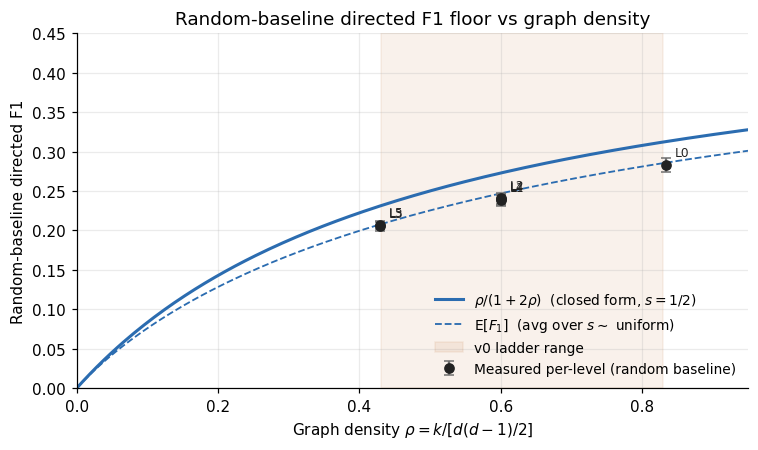

Max |measured - theory_midpoint| across levels: 0.0345 (3.45 pp)


In [4]:
rho_grid = np.linspace(0.0, 0.95, 200)
fig, ax = plt.subplots(figsize=(7.0, 4.2))

ax.plot(rho_grid, closed_form_midpoint(rho_grid), color=ACCENT, lw=2,
        label=r"$\rho/(1+2\rho)$  (closed form, $s=1/2$)")
ax.plot(rho_grid, expected_f1_marginal(rho_grid), color=ACCENT, lw=1.2, ls="--",
        label=r"E[$F_1$]  (avg over $s\sim$ uniform)")

ax.errorbar(per_level["rho"], per_level["f1_mean"], yerr=per_level["f1_se"],
            fmt="o", color=INK, ecolor=MUTED, ms=6, capsize=3, zorder=5,
            label="Measured per-level (random baseline)")
for _, row in per_level.iterrows():
    ax.annotate(f"L{int(row['level'])}", (row["rho"], row["f1_mean"]),
                xytext=(6, 6), textcoords="offset points", fontsize=8, color=INK)

ax.axvspan(0.43, 0.83, color=ACCENT2, alpha=0.08, label="v0 ladder range")

ax.set_xlabel(r"Graph density $\rho = k / [d(d-1)/2]$")
ax.set_ylabel("Random-baseline directed F1")
ax.set_title("Random-baseline directed F1 floor vs graph density")
ax.set_xlim(0, 0.95); ax.set_ylim(0, 0.45)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

gap = (per_level["f1_mean"] - per_level["theory_midpoint"]).abs().max()
print(f"Max |measured - theory_midpoint| across levels: {gap:.4f} ({gap*100:.2f} pp)")

**What to read off Plot 1.**

- The closed form `ρ/(1+2ρ)` is monotone but **flattens past ρ ≈ 0.4**. Its asymptote at $\rho \to \infty$ is $\tfrac{1}{2}$ — the "direction is 50/50" tax even on a complete graph.
- All v0 non-tutorial levels (L1–L5) sit at ρ ∈ [0.43, 0.60], which is the flat region. Halving density there moves the floor only ~5 pp.
- The steep region is ρ ≲ 0.3, where small density changes meaningfully shift the floor.
- v0's density was high enough that the random baseline scores ~24% directed F1 — a high bar to read LLM signal against.

## Plot 2 — Conditional curves over s

Hold ρ fixed, sweep submission rate $s = m/M$. Shows how aggressive submission moves expected F1 at each density.

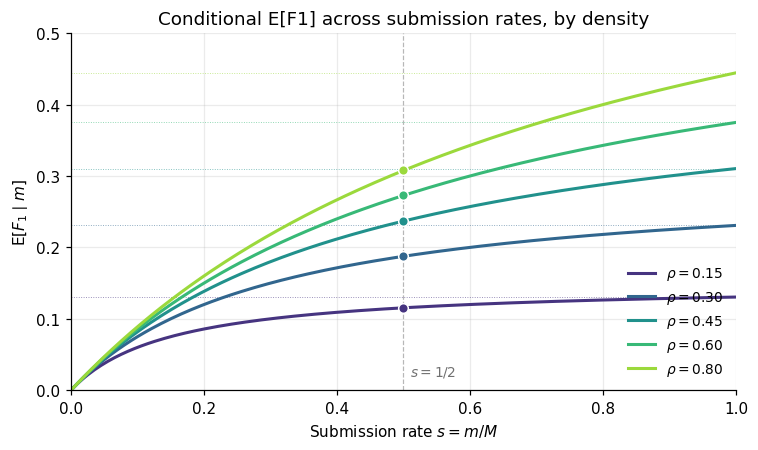

Submission-rate sensitivity (F1 swing from s=0.3 to s=0.7):
  rho = 0.15: dF1 = 2.4 pp
  rho = 0.30: dF1 = 6.0 pp
  rho = 0.45: dF1 = 9.4 pp
  rho = 0.60: dF1 = 12.3 pp
  rho = 0.80: dF1 = 15.5 pp


In [5]:
s_grid = np.linspace(0.0, 1.0, 200)
rho_values = [0.15, 0.30, 0.45, 0.60, 0.80]
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(rho_values)))

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for rho, color in zip(rho_values, cmap):
    f1 = expected_f1_conditional(rho, s_grid)
    ax.plot(s_grid, f1, color=color, lw=2, label=fr"$\rho={rho:.2f}$")
    ax.scatter([0.5], [expected_f1_conditional(rho, 0.5)], color=color, s=40, zorder=5,
               edgecolor="white", linewidth=1.0)
    ax.axhline(rho / (1 + rho), color=color, lw=0.6, ls=":", alpha=0.6)

ax.axvline(0.5, color=MUTED, lw=0.8, ls="--", alpha=0.5)
ax.text(0.51, 0.02, r"$s=1/2$", fontsize=9, color=MUTED)

ax.set_xlabel(r"Submission rate $s = m / M$")
ax.set_ylabel(r"E[$F_1 \mid m$]")
ax.set_title("Conditional E[F1] across submission rates, by density")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.5)
ax.legend(loc="lower right", frameon=False, fontsize=9, ncol=1)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("Submission-rate sensitivity (F1 swing from s=0.3 to s=0.7):")
for rho in rho_values:
    swing = expected_f1_conditional(rho, 0.7) - expected_f1_conditional(rho, 0.3)
    print(f"  rho = {rho:.2f}: dF1 = {swing*100:.1f} pp")

**What to read off Plot 2.**

- Curves are monotone-increasing in $s$ and asymptote to $\rho/(1+\rho)$ at $s=1$ (dotted lines).
- At ρ = 0.60, going from $s=0.3$ to $s=0.7$ swings expected F1 by ~12 pp. At ρ = 0.15, the same $s$-swing moves F1 by only ~5 pp.
- **Implication:** lower-density ladders are *less sensitive to submission strategy*. F1 measures more causal reasoning and less guessing aggressiveness. This is a second argument for low-ρ v1 beyond "lower the floor."
- This is also why LLM over-commit / PC under-commit produced such different F1s in v0 — the operating density amplifies the sensitivity to that asymmetry.

## Plot 3 — Skill-margin schematic

v0 region (ρ ≈ 0.43–0.83) vs a candidate v1 region (ρ ≲ 0.30). Annotated to show the floor each region produces and the *steepness* of the curve traversed within it.

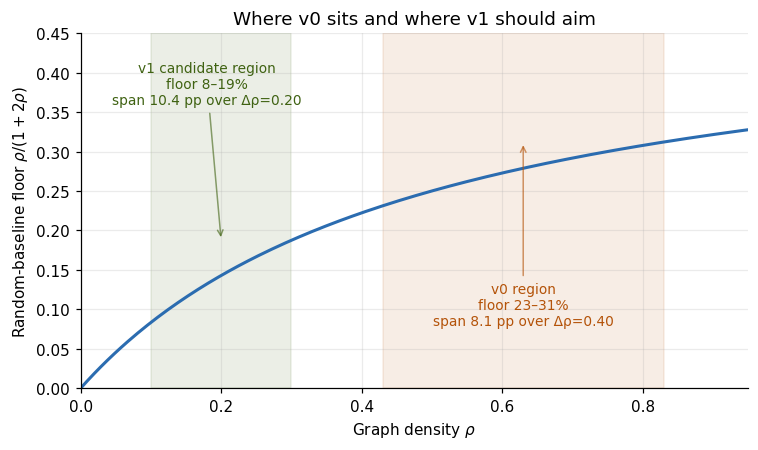

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(rho_grid, closed_form_midpoint(rho_grid), color=ACCENT, lw=2)

ax.axvspan(0.43, 0.83, color=ACCENT2, alpha=0.10)
ax.axvspan(0.10, 0.30, color="#3f6212", alpha=0.10)

v0_lo, v0_hi = closed_form_midpoint(0.43), closed_form_midpoint(0.83)
v1_lo, v1_hi = closed_form_midpoint(0.10), closed_form_midpoint(0.30)

ax.annotate(f"v0 region\nfloor {v0_lo*100:.0f}–{v0_hi*100:.0f}%\nspan {(v0_hi-v0_lo)*100:.1f} pp over Δρ=0.40",
            xy=(0.63, v0_hi), xytext=(0.63, 0.08), fontsize=9, color=ACCENT2,
            ha="center", arrowprops=dict(arrowstyle="->", color=ACCENT2, alpha=0.6))
ax.annotate(f"v1 candidate region\nfloor {v1_lo*100:.0f}–{v1_hi*100:.0f}%\nspan {(v1_hi-v1_lo)*100:.1f} pp over Δρ=0.20",
            xy=(0.20, v1_hi), xytext=(0.18, 0.36), fontsize=9, color="#3f6212",
            ha="center", arrowprops=dict(arrowstyle="->", color="#3f6212", alpha=0.6))

ax.set_xlabel(r"Graph density $\rho$")
ax.set_ylabel(r"Random-baseline floor $\rho/(1+2\rho)$")
ax.set_title("Where v0 sits and where v1 should aim")
ax.set_xlim(0, 0.95); ax.set_ylim(0, 0.45)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Calibration table — target floor → ρ

Inverting `floor = ρ/(1+2ρ)` gives $\rho = \text{floor} / (1 - 2 \cdot \text{floor})$. (Valid for floor < 0.5; the formula's asymptote.)

Use this to pick a target floor for v1's identifiability axis. Concrete (d, k) choices to hit the chosen ρ are deferred — picking those is a topology decision (chain depth, v-structures, fork count) that this notebook does not address.

In [ ]:
def rho_for_floor(floor):
    return floor / (1.0 - 2.0 * floor)


targets = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]
table = pd.DataFrame({
    "target_floor": targets,
    "rho": [rho_for_floor(f) for f in targets],
})
table["verify_floor"] = closed_form_midpoint(table["rho"].values)
table.round(4)

,target_floor,rho,verify_floor
0,0.05,0.0556,0.05
1,0.08,0.0952,0.08
2,0.10,0.1250,0.10
3,0.12,0.1579,0.12
4,0.15,0.2143,0.15
5,0.18,0.2812,0.18
6,0.20,0.3333,0.20
7,0.25,0.5000,0.25
8,0.30,0.7500,0.30


: 

## Caveats

1. **The floor is for a structure-blind random baseline.** PC, LLMs, oracle do not sit on this curve. The curve only bounds *how much directed-F1 signal is achievable without using data*. Calibrating against it sets the noise floor, not a skill ceiling.
2. **m-uniform assumption.** The closed form `ρ/(1+2ρ)` assumes the baseline draws $m$ uniformly on $\{0, \ldots, M\}$. If a future random baseline draws $m$ from a different distribution (e.g., concentrated near $m \approx k$), the floor shifts. Plot 2 shows how much.
3. **Density is not the only difficulty knob.** Two graphs with the same ρ can differ in chain depth, v-structure count, and fork count — and recent work (Sangala et al., 2026) finds LLMs handle individual mechanisms but struggle to compose chains. A density-calibrated v1 ladder still needs a topology-aware second axis to test composition skill.
4. **Recommended next step.** Before committing to v1 ρ values, run a *counterfactual probe*: simulate the random + PC baselines at the proposed v1 ρ on a small seed batch. Confirm the curve's prediction empirically before re-running the full ladder.